# k-Nearest Neighbor Algorithm for Iris Dataset Classification

In this notebook, we'll implement the k-Nearest Neighbor (k-NN) algorithm to classify the Iris dataset.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import matplotlib.colors as mcolors

# Set up plotting style
plt.style.use('seaborn')
%matplotlib inline

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Part 1: Loading and Exploring the Dataset

Let's first load the Iris dataset and explore its basic characteristics.

In [3]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier data handling
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display basic information
print("Iris Dataset Shape:", iris_df.shape)
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nFeatures:")
print(iris.feature_names)
print("\nTarget Classes:")
print(iris.target_names)
print("\nSummary Statistics:")
print(iris_df.describe())
print("\nClass Distribution:")
print(iris_df['species'].value_counts())

Iris Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866    

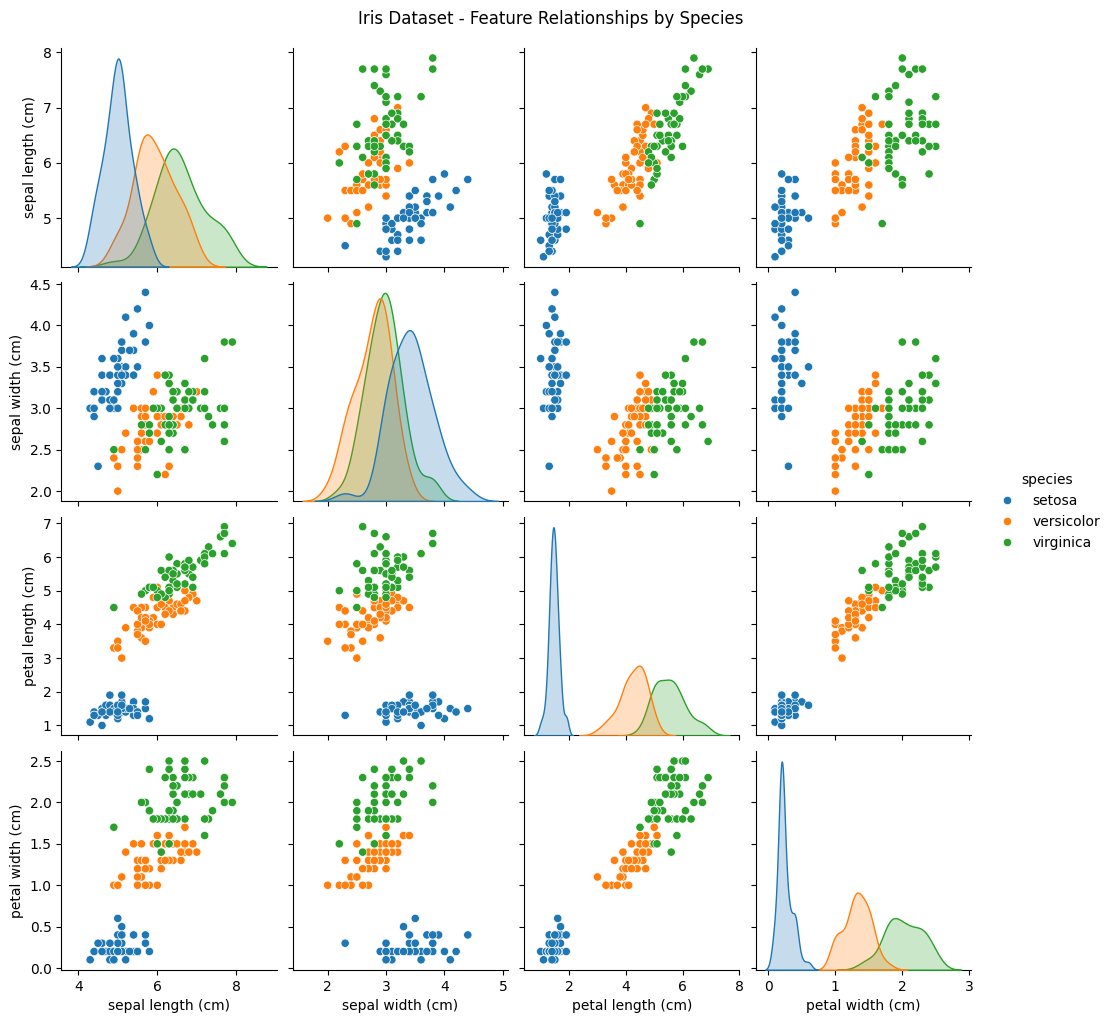

In [4]:
# Visualize the Iris dataset
# Create a pair plot to visualize relationships between features
sns.pairplot(iris_df, hue='species', height=2.5)
plt.suptitle('Iris Dataset - Feature Relationships by Species', y=1.02)
plt.show()

## Part 2: Implementing k-NN Algorithm from Scratch

Now, let's implement the k-Nearest Neighbor algorithm from scratch.

In [5]:
class KNNClassifier:
    def __init__(self, k=3):
        """Initialize KNN classifier with k neighbors"""
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        return self
    
    def _euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance between two points"""
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict(self, X):
        """Predict classes for samples in X"""
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)
    
    def _predict_single(self, x):
        """Predict class for a single sample"""
        # Calculate distances to all training samples
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get labels of k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Return most common class label
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

## Part 3: Preparing Data for Classification

Let's split the dataset into training and testing sets.

In [6]:
# Prepare data
X = iris.data
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display data shapes
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (120, 4)
Testing data shape: (30, 4)


## Part 4: Evaluating Our Implementation

Let's test our KNN implementation on the Iris dataset.

In [7]:
# Create and train our custom KNN classifier
custom_knn = KNNClassifier(k=3)
custom_knn.fit(X_train_scaled, y_train)

# Make predictions
custom_predictions = custom_knn.predict(X_test_scaled)

# Calculate accuracy
custom_accuracy = accuracy_score(y_test, custom_predictions)
print(f"Custom KNN Classifier Accuracy: {custom_accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, custom_predictions, target_names=iris.target_names))

# Display confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, custom_predictions)
print(conf_matrix)

Custom KNN Classifier Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


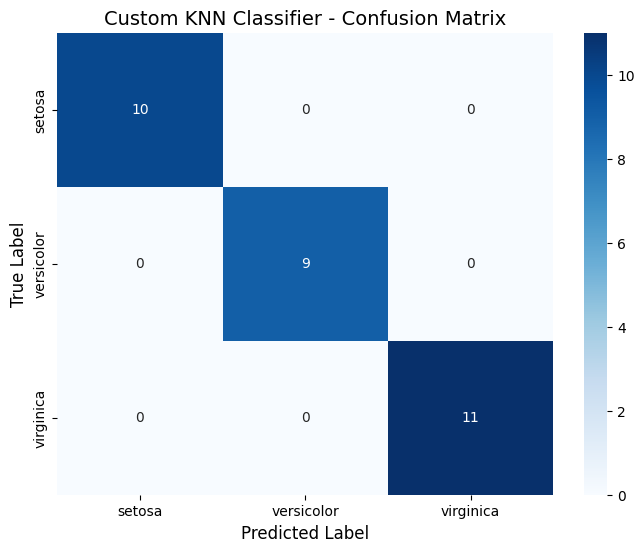

In [8]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Custom KNN Classifier - Confusion Matrix', fontsize=14)
plt.show()

## Part 5: Using Scikit-learn's KNN Implementation

Now, let's compare our implementation with scikit-learn's KNeighborsClassifier.

In [9]:
# Create and train scikit-learn's KNN classifier
sklearn_knn = KNeighborsClassifier(n_neighbors=3)
sklearn_knn.fit(X_train_scaled, y_train)

# Make predictions
sklearn_predictions = sklearn_knn.predict(X_test_scaled)

# Calculate accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-learn KNN Classifier Accuracy: {sklearn_accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, sklearn_predictions, target_names=iris.target_names))

# Display confusion matrix
sklearn_conf_matrix = confusion_matrix(y_test, sklearn_predictions)
print("\nConfusion Matrix:")
print(sklearn_conf_matrix)

Scikit-learn KNN Classifier Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Part 6: Finding the Optimal K Value

Let's try different values of k to find the optimal one.

In [10]:
# Test different k values
k_values = list(range(1, 31, 2))  # Test odd values of k from 1 to 30
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)
    print(f"k = {k}, Accuracy = {accuracy * 100:.2f}%")

# Find the best k value
best_k_index = np.argmax(accuracies)
best_k = k_values[best_k_index]
best_accuracy = accuracies[best_k_index]
print(f"\nBest k value: {best_k} with accuracy: {best_accuracy * 100:.2f}%")

k = 1, Accuracy = 100.00%
k = 3, Accuracy = 100.00%
k = 5, Accuracy = 100.00%
k = 7, Accuracy = 100.00%
k = 9, Accuracy = 100.00%
k = 11, Accuracy = 100.00%
k = 13, Accuracy = 100.00%
k = 15, Accuracy = 100.00%
k = 17, Accuracy = 100.00%
k = 19, Accuracy = 100.00%
k = 21, Accuracy = 100.00%
k = 23, Accuracy = 100.00%
k = 25, Accuracy = 100.00%
k = 27, Accuracy = 100.00%
k = 29, Accuracy = 96.67%

Best k value: 1 with accuracy: 100.00%


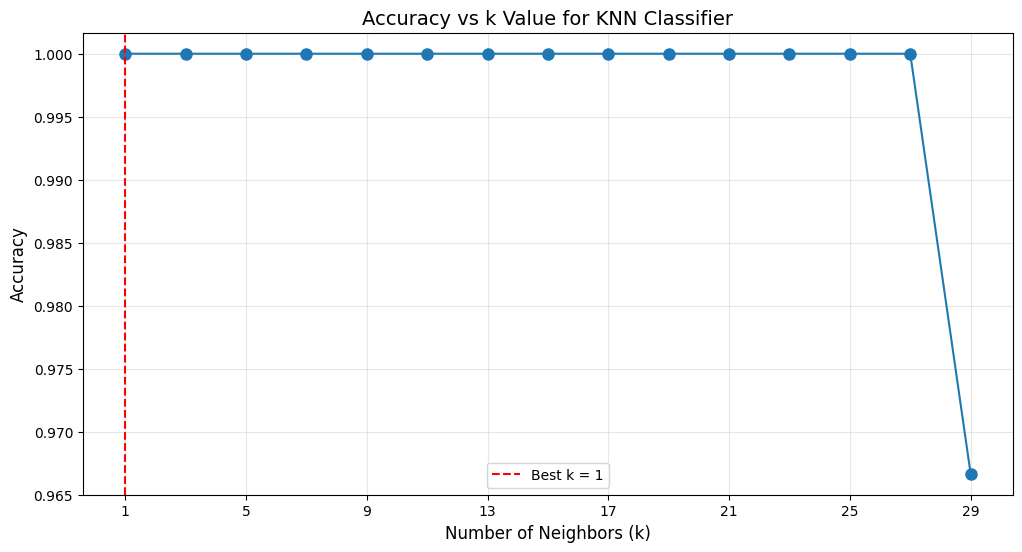

In [11]:
# Plot accuracy vs k values
plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracies, marker='o', markersize=8, linestyle='-')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title('Accuracy vs k Value for KNN Classifier', fontsize=14)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values[::2])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Part 7: Visualizing KNN Decision Boundaries

Let's visualize the decision boundaries created by our KNN classifier using two features.

In [12]:
# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model, feature_indices=(0, 1)):
    # Extract the two features for visualization
    X_subset = X[:, feature_indices]
    
    # Create a mesh grid for plotting decision boundaries
    h = 0.02  # Step size in the mesh
    x_min, x_max = X_subset[:, 0].min() - 1, X_subset[:, 0].max() + 1
    y_min, y_max = X_subset[:, 1].min() - 1, X_subset[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Create all points in the mesh grid
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Prepare full-dimensional points with zeros for non-visualized dimensions
    full_points = np.zeros((mesh_points.shape[0], X.shape[1]))
    full_points[:, feature_indices] = mesh_points
    
    # Predict class for each point in the mesh grid
    Z = model.predict(full_points)
    Z = Z.reshape(xx.shape)
    
    # Create a colormap
    colors = ['#FF9999', '#66B2FF', '#99FF99']
    cmap = mcolors.ListedColormap(colors[:len(np.unique(y))])
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    
    # Plot the data points
    for i, color in zip(range(len(np.unique(y))), colors):
        plt.scatter(X_subset[y == i, 0], X_subset[y == i, 1], 
                    c=color, label=iris.target_names[i], edgecolors='k', s=80, alpha=0.7)
    
    # Add labels and title
    plt.xlabel(iris.feature_names[feature_indices[0]], fontsize=12)
    plt.ylabel(iris.feature_names[feature_indices[1]], fontsize=12)
    plt.title(f'KNN Decision Boundaries (k={model.n_neighbors})', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

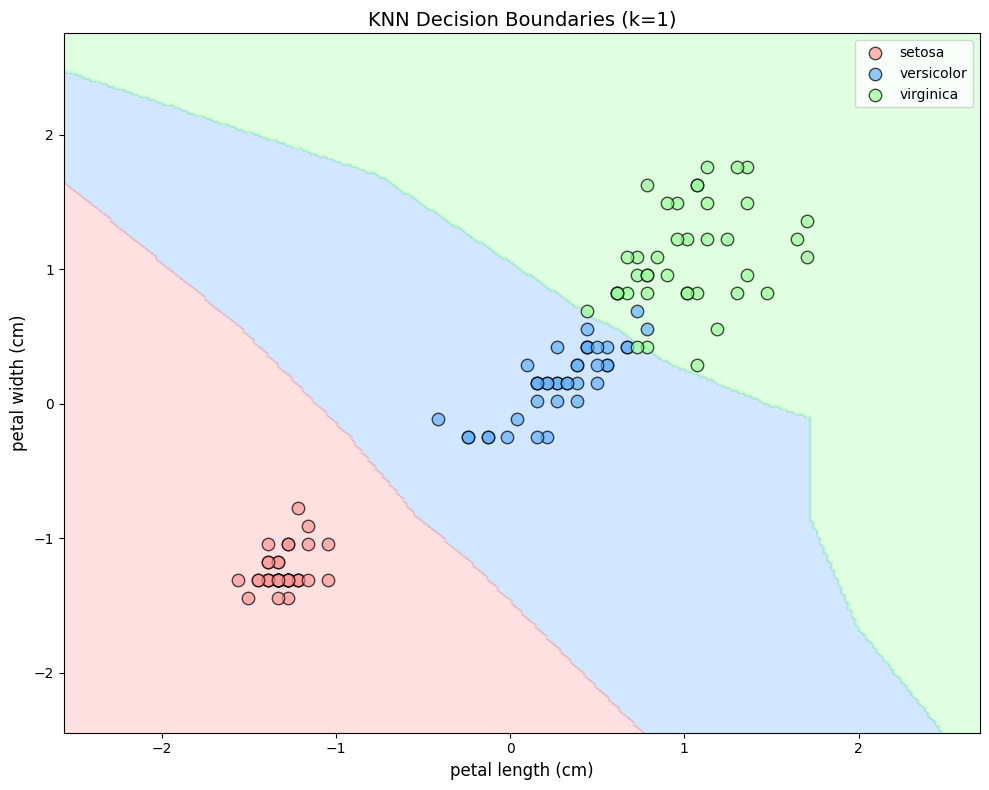

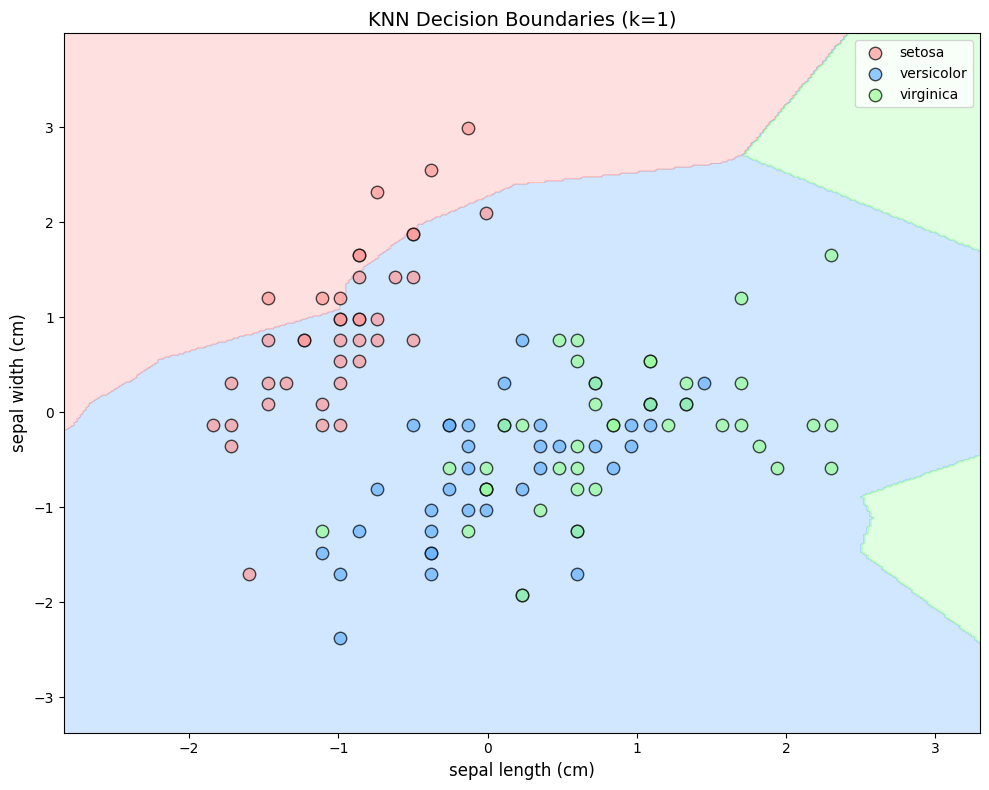

In [13]:
# Visualize decision boundaries for different feature pairs
# Use the best k value we found
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Visualize petal length vs petal width
plot_decision_boundaries(X_train_scaled, y_train, best_knn, feature_indices=(2, 3))

# Visualize sepal length vs sepal width
plot_decision_boundaries(X_train_scaled, y_train, best_knn, feature_indices=(0, 1))

## Part 8: Making Predictions on New Data

Let's try our KNN model on some new data points.

In [14]:
# Create sample data points
new_samples = [
    [5.1, 3.5, 1.4, 0.2],  # Likely setosa
    [6.3, 3.3, 4.7, 1.6],  # Likely versicolor
    [6.5, 3.0, 5.2, 2.0],  # Likely virginica
    [5.9, 3.0, 4.2, 1.5],  # Ambiguous case
]

# Scale the new samples
new_samples_scaled = scaler.transform(new_samples)

# Predict using our best KNN model
predictions = best_knn.predict(new_samples_scaled)
probabilities = best_knn.predict_proba(new_samples_scaled)

# Display results
print("Predictions for new samples:")
for i, (sample, prediction, proba) in enumerate(zip(new_samples, predictions, probabilities)):
    predicted_species = iris.target_names[prediction]
    print(f"\nSample {i+1}: {sample}")
    print(f"Predicted species: {predicted_species}")
    print("Class probabilities:")
    for j, p in enumerate(proba):
        print(f"  {iris.target_names[j]}: {p:.4f} ({p*100:.2f}%)")

Predictions for new samples:

Sample 1: [5.1, 3.5, 1.4, 0.2]
Predicted species: setosa
Class probabilities:
  setosa: 1.0000 (100.00%)
  versicolor: 0.0000 (0.00%)
  virginica: 0.0000 (0.00%)

Sample 2: [6.3, 3.3, 4.7, 1.6]
Predicted species: versicolor
Class probabilities:
  setosa: 0.0000 (0.00%)
  versicolor: 1.0000 (100.00%)
  virginica: 0.0000 (0.00%)

Sample 3: [6.5, 3.0, 5.2, 2.0]
Predicted species: virginica
Class probabilities:
  setosa: 0.0000 (0.00%)
  versicolor: 0.0000 (0.00%)
  virginica: 1.0000 (100.00%)

Sample 4: [5.9, 3.0, 4.2, 1.5]
Predicted species: versicolor
Class probabilities:
  setosa: 0.0000 (0.00%)
  versicolor: 1.0000 (100.00%)
  virginica: 0.0000 (0.00%)


## Conclusion

In this notebook, we've successfully implemented and explored the k-Nearest Neighbor algorithm for classifying the Iris dataset. We:

1. Implemented the KNN algorithm from scratch
2. Compared our implementation with scikit-learn's KNN classifier
3. Found the optimal k value for the given dataset
4. Visualized the decision boundaries for different feature combinations
5. Made predictions on new, unseen data points

The KNN algorithm is a simple yet powerful classification algorithm that works by finding the k closest training examples and using majority voting to determine the class of a new data point. While it's easy to implement and understand, it's important to note that KNN can be computationally expensive for large datasets, as it requires calculating distances to all training examples for each prediction.